# ✈️ Flight Price Prediction 💰

Ever wondered **how much your flight will cost** before booking? 🤔  
This project predicts flight ticket prices using machine learning and historical flight data from Kaggle 📊. By analyzing factors like **airline ✈️, route 🌍, departure & arrival times ⏰, flight duration ⏳, and number of stops 🛑**, we can estimate the price of a ticket 💵.

Whether you’re a **traveler looking for the best deal 💸** or a **data enthusiast exploring predictive modeling 📈**, this project gives you insights into flight pricing trends and helps make **smarter booking decisions**.


### 🧠 Key Questions 

- Which airline has the highest average price?
- Are night flights cheaper?
- Does longer duration increase price?
- How does price change as days_left decreases?
- Is it cheaper to book early?
- How fast does price increase when departure date approaches?

### 📥 Loading the Dataset and Libraries

Before we start predicting flight prices, we need to install the necessary Python libraries and **load the dataset**.


In [1]:
# Install the required libraries
%pip install pandas numpy matplotlib seaborn scikit-learn -q 
# Install and update the watermark package to display environment and library version information
%pip install -q -U watermark

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing the library for data manipulation in tables
import pandas as pd 

# Importing the NumPy library for mathematical operations and arrays
import numpy as np  

# Importing the Matplotlib library for generating plots
import matplotlib.pyplot as plt  

# Importing the Seaborn library for statistical data visualization
import seaborn as sns  

from sklearn.linear_model import LinearRegression

# Jupyter Notebook magic command to display plots directly in the notebook
%matplotlib inline

In [3]:
# Load the watermark extension
%reload_ext watermark

# Display metadata for your notebook
%watermark -a "Maykon Analysis - Flight Price Prediction" -d -u -v -p numpy,pandas,matplotlib,seaborn

Author: Maykon Analysis - Flight Price Prediction

Last updated: 2026-02-24

Python implementation: CPython
Python version       : 3.12.8
IPython version      : 9.10.0

numpy     : 2.4.2
pandas    : 3.0.1
matplotlib: 3.10.8
seaborn   : 0.13.2



In [4]:
# Load the Flight Price dataset from a local CSV file into a pandas DataFrame
data = r"data\flightprice.csv"

df = pd.read_csv(data)

In [5]:
df.head() #Displays the first rows of the DataFrame df. 

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


### 📊 Exploratory Data Analysis (EDA)
I will now begin the exploratory data analysis to better understand the dataset. In this step, I will examine the structure of the data, analyze statistical summaries, identify missing values, and explore relationships between the features and the flight price. This will help uncover patterns and insights to guide the regression modeling process.

In [7]:
df.describe(include='number') # Generates summary statistics for all numerical columns in the DataFrame.

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [8]:
df.describe(include='str') # Generates summary statistics only for string (text) columns in the DataFrame.

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [9]:
df.describe(include='all') #Generates a complete statistical summary of the DataFrame.

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
count,300153.000000,300153,300153,300153,300153,300153,300153,300153,300153,300153.000000,300153.000000,300153.000000
unique,NaN,6,1561,6,6,3,6,6,2,NaN,NaN,NaN
top,NaN,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy,NaN,NaN,NaN
freq,NaN,127859,3235,61343,71146,250863,91538,59097,206666,NaN,NaN,NaN
mean,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.221021,26.004751,20889.660523
std,86646.852011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.191997,13.561004,22697.767366
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.830000,1.000000,1105.000000
25%,75038.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.830000,15.000000,4783.000000
50%,150076.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.250000,26.000000,7425.000000
75%,225114.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.170000,38.000000,42521.000000


In [10]:
df.info() #Displays a summary of the DataFrame structure. 

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 27.5 MB


In [11]:
df.shape # (rows, columns)

(300153, 12)

In [12]:
df.sample(5) # Random 5 rows

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
37877,37877,Vistara,UK-993,Delhi,Afternoon,one,Night,Chennai,Economy,10.25,19,4979
10027,10027,Air_India,AI-512,Delhi,Afternoon,one,Evening,Bangalore,Economy,26.42,1,12150
285830,285830,Air_India,AI-525,Hyderabad,Early_Morning,one,Night,Chennai,Business,17.17,13,39682
109674,109674,Vistara,UK-820,Bangalore,Evening,one,Morning,Hyderabad,Economy,15.83,1,13258
235031,235031,Vistara,UK-960,Mumbai,Morning,one,Evening,Kolkata,Business,7.67,13,62045


In [13]:
df.dtypes #Displays the data type of each column in the DataFrame.

Unnamed: 0            int64
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
dtype: object

In [14]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='str')

### 📊 Why Perform Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is an essential step before building a regression model.

We perform EDA to:

- 🔍 Understand the structure of the dataset  
- 📈 Analyze the distribution of variables  
- 🧹 Detect missing values and inconsistencies  
- 📊 Identify relationships between features and the target variable  
- 🚨 Detect outliers that may affect the model  
- 🎯 Select relevant features for modeling  

EDA helps uncover patterns, trends, and potential issues in the data.

**In short:**  
EDA allows us to understand the data deeply before building and training a machine learning model.

### 🧹 Data Cleaning

After completing the exploratory data analysis, the next step is data cleaning.

In this stage, I will handle missing values, remove or treat outliers, correct data types if necessary, and ensure the dataset is consistent and ready for modeling.

Data cleaning is essential to improve data quality and ensure that the regression model produces accurate and reliable results.

In [15]:
df.isnull().sum() # Count missing values per column

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [16]:
# Example conversion
df['price_usd'] = df['price'] * 0.012  # converting INR to USD

In [17]:
# Drop useless columns
df.drop(columns=['Unnamed: 0', 'flight', 'price'], inplace=True)

In [18]:
df.duplicated().sum() # Count duplicates

np.int64(2213)

In [19]:
df.head(10) #Displays the first rows of the DataFrame df.

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,71.436
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,71.436
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,71.472
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,71.460
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,71.460
5,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,71.460
6,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,72.720
7,Vistara,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,72.720
8,GO_FIRST,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,71.448
9,GO_FIRST,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,71.448


In [22]:
dfc = df.copy() #It creates a new independent copy of the DataFrame.

In [23]:
dfc.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price_usd
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,71.436
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,71.436
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,71.472
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,71.460
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,71.460


In [24]:
dfc.dtypes

airline                 str
source_city             str
departure_time          str
stops                   str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price_usd           float64
dtype: object

In [ ]:
dfc.sample(10)

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,price_usd
177521,Vistara,Hyderabad,Early_Morning,one,Night,Chennai,Economy,15.92,17,5409,64.908
146196,Indigo,Kolkata,Morning,one,Evening,Hyderabad,Economy,8.58,34,3401,40.812
193945,Air_India,Chennai,Morning,one,Late_Night,Bangalore,Economy,14.25,3,21843,262.116
184,Vistara,Delhi,Evening,one,Night,Mumbai,Economy,4.42,2,12570,150.840
171266,Vistara,Hyderabad,Early_Morning,one,Evening,Kolkata,Economy,12.75,7,12747,152.964
33500,GO_FIRST,Delhi,Morning,one,Afternoon,Hyderabad,Economy,6.50,37,3989,47.868
147561,Vistara,Kolkata,Night,one,Night,Hyderabad,Economy,26.58,45,5632,67.584
51840,Indigo,Mumbai,Early_Morning,one,Afternoon,Delhi,Economy,6.25,45,2339,28.068
217643,Air_India,Delhi,Evening,one,Night,Kolkata,Business,5.67,28,53209,638.508
39715,Indigo,Delhi,Morning,one,Afternoon,Chennai,Economy,5.42,30,2916,34.992


In [25]:
dfc.columns

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price_usd'],
      dtype='str')

#### 🧹 Data Cleaning Process (Summary)

_During the cleaning stage, I prepared the dataset for regression analysis by handling missing values, correcting data types, and removing redundant columns to avoid multicollinearity. I also prepared categorical variables for encoding, since regression models require numerical inputs._

#### 🔎 Before building regression models to predict flight prices
 I performed structured data analysis to better understand the dataset and identify the key factors influencing ticket prices. Since this is a regression problem with price as the target variable, the analysis focuses on answering the central question:

**Which factors most strongly affect flight price?**

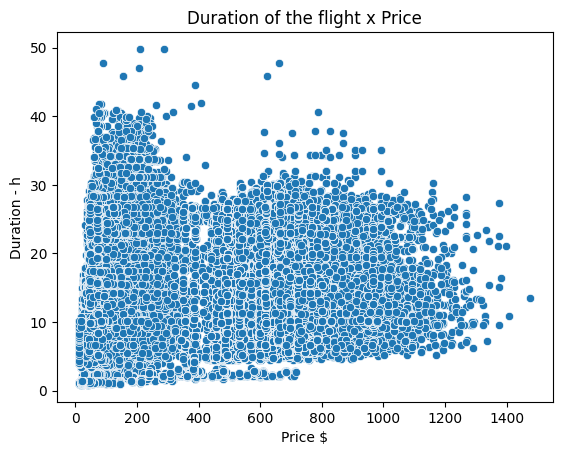

' This scatter plot shows the relationship between flight duration and ticket price. \nIt helps identify whether longer flights tend to be more expensive and whether a linear relationship exists between these variables. \nThe distribution of points also allows the detection of variability and possible outliers that could affect the regression model.'

In [ ]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='price_usd', y='duration')
plt.xlabel('Price $')
plt.ylabel('Duration - h')
plt.show()

""" This scatter plot shows the relationship between flight duration and ticket price. 
It helps identify whether longer flights tend to be more expensive and whether a linear relationship exists between these variables. 
The distribution of points also allows the detection of variability and possible outliers that could affect the regression model."""

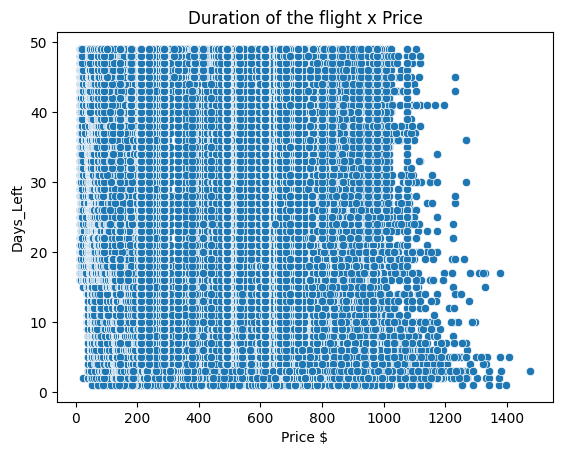

In [ ]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='price_usd', y='days_left')
plt.xlabel('Price $')
plt.ylabel('Days_Left')
plt.show()

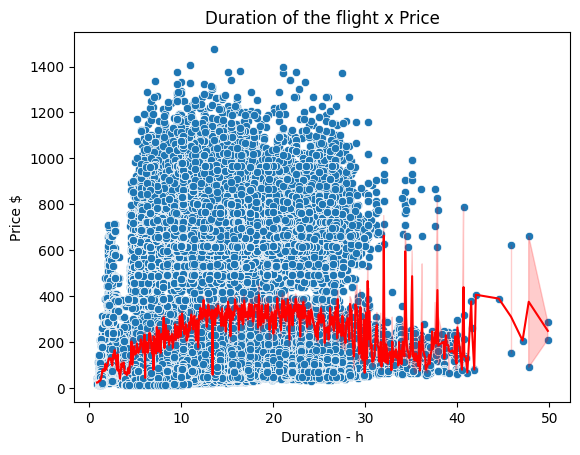

In [ ]:
plt.title('Duration of the flight x Price')
sns.scatterplot(data=dfc, x='duration', y='price_usd')
sns.lineplot(data=dfc, x='duration', y='price_usd', color='red')
plt.xlabel('Duration - h')
plt.ylabel('Price $')
plt.show()

The plot shows that most flight prices are concentrated between approximately $20,000 and $40,000 across different durations. Although there are some peaks reaching $60,000 to $80,000, these values are not frequent and likely represent specific flights or outliers.

The red trend line suggests a mild positive relationship between duration and price for short to medium flights, but the pattern is not strongly linear. The high dispersion of points indicates that duration alone does not strongly determine ticket price, and other variables likely have significant influence in the regression model.

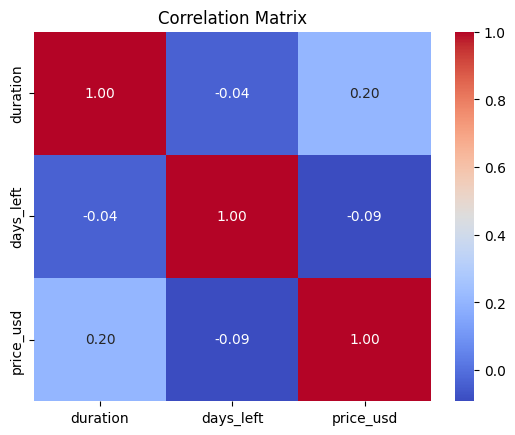

In [ ]:
numeric_features = ['duration', 'days_left', 'price_usd']
corr_matrix = dfc[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

- None of these variables show strong correlation with each other.

- "duration" and "price" have a slight positive relationship.

- The others are nearly independent in a linear sense.

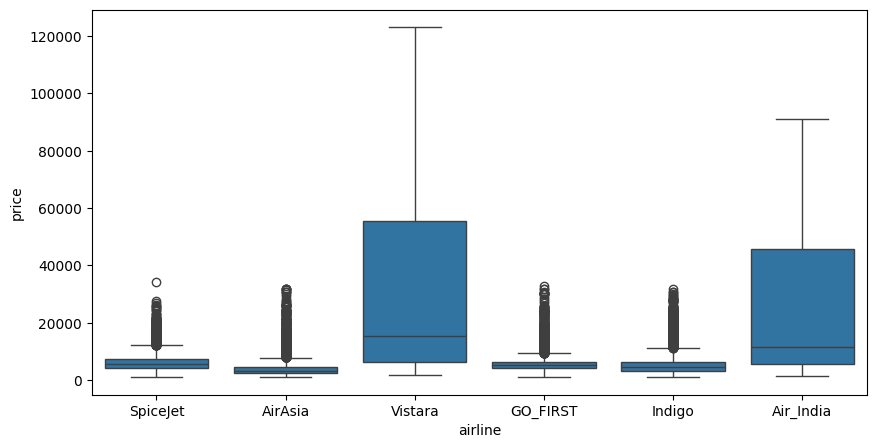

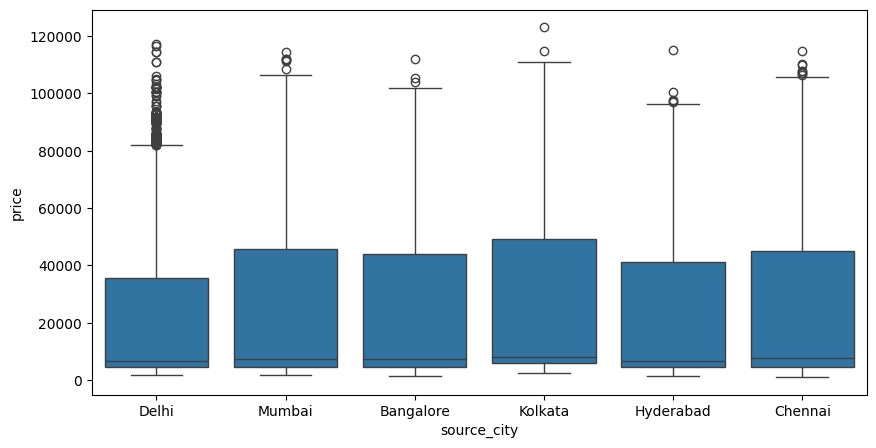

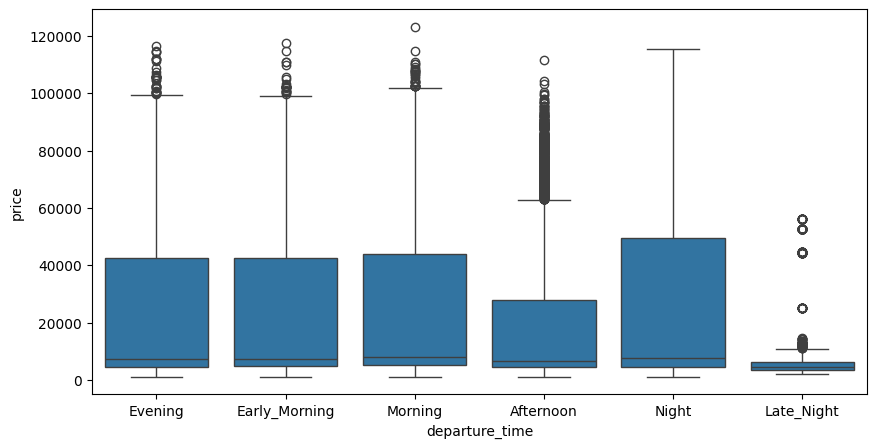

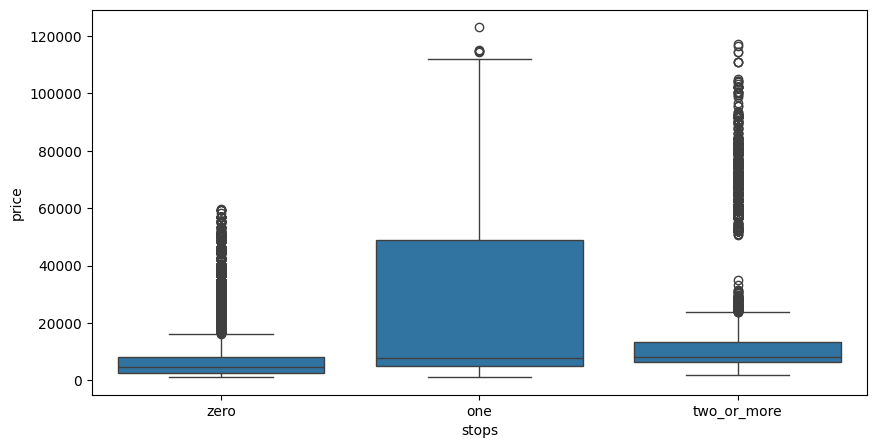

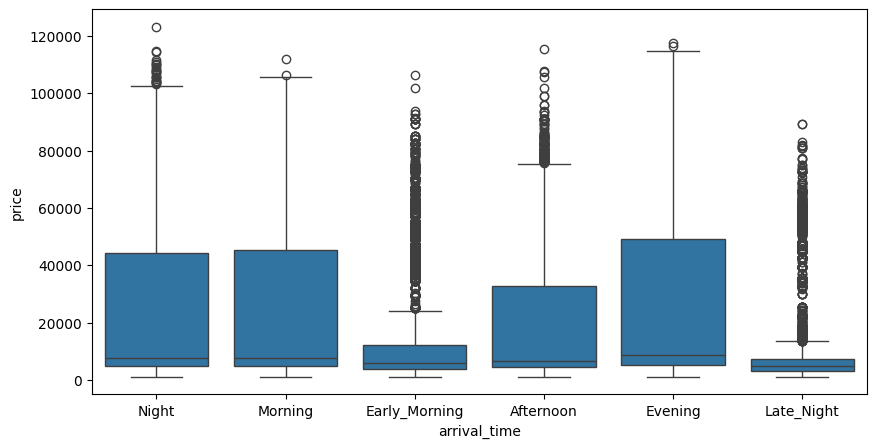

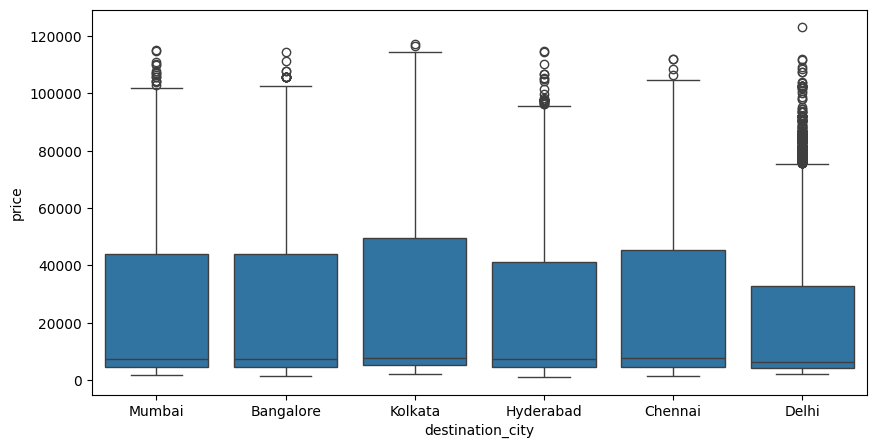

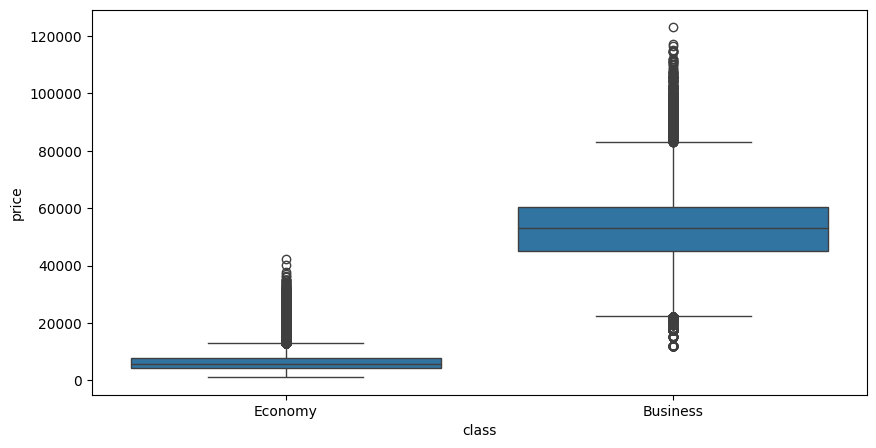

In [ ]:
features = ['airline','source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

categorical_features = ['airline','source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

for col in categorical_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col, y='price', data=dfc)

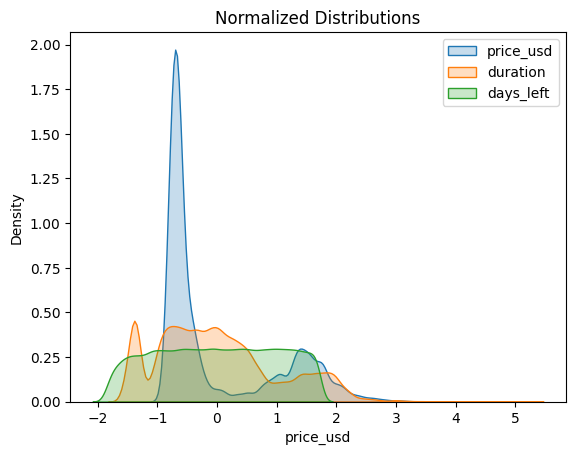

In [32]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = ['price_usd', 'duration', 'days_left']

scaler = StandardScaler()
scaled = scaler.fit_transform(dfc[features])

scaled_df = pd.DataFrame(scaled, columns=features)

for col in features:
    sns.kdeplot(scaled_df[col], fill=True, label=col)

plt.title('Normalized Distributions')
plt.legend()
plt.show()